第二次测序的new样本处理全流程
输出全部在/p2/zulab/jtian/data/IRISeq/second/output/my-second-pipeline/old

In [1]:
from pathlib import Path
import os
import sys
import gzip
import json
import shutil
import hashlib
import importlib
import subprocess
import warnings
import scanpy as sc
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option('display.max_colwidth', None)   # 单元格内容不截断
pd.set_option('display.max_columns', None)    # 显示所有列
pd.set_option('display.width', None)          # 自动适配宽度
pd.set_option('display.max_rows', 200)        # 需要时显示更多行
# The second dataset is organized as old-cDNA/new-cDNA and old-beads/new-beads.
# Change this to 'old' to process the old-* FASTQ pair instead.
DATASET_VERSION = 'old'

In [2]:
PROJECT_DIR = Path('/p1/zulab_users/jtian/my_jupyter/IRI-seq')
SCRIPT_FROM_GITHUB = PROJECT_DIR / 'script_from_github'
INPUT_DIR = Path('/p2/zulab/jtian/data/IRISeq/second/data/Data')
OUTPUT_ROOT = Path('/p2/zulab/jtian/data/IRISeq/second/output/my-second-pipeline')
OUTPUT_DIR = OUTPUT_ROOT / DATASET_VERSION
REFERENCE_DIR = Path('/p2/zulab/jtian/data/IRISeq/reference')


CDNA_SAMPLE = f'{DATASET_VERSION}-cDNA'
BEAD_SAMPLE = f'{DATASET_VERSION}-beads'
SAMPLE_ID = DATASET_VERSION
OUTPUT_PREFIX = SAMPLE_ID

FASTQ_SOURCE_FILES = {
    CDNA_SAMPLE: {
        'run_accession': CDNA_SAMPLE,
        'description': f'second dataset {DATASET_VERSION} cDNA',
        'R1': INPUT_DIR / CDNA_SAMPLE / f'{CDNA_SAMPLE}_R1.fq.gz',
        'R2': INPUT_DIR / CDNA_SAMPLE / f'{CDNA_SAMPLE}_R2.fq.gz',
    },
    BEAD_SAMPLE: {
        'run_accession': BEAD_SAMPLE,
        'description': f'second dataset {DATASET_VERSION} bead interaction',
        'R1': INPUT_DIR / BEAD_SAMPLE / f'{BEAD_SAMPLE}_R1.fq.gz',
        'R2': INPUT_DIR / BEAD_SAMPLE / f'{BEAD_SAMPLE}_R2.fq.gz',
        'R3': INPUT_DIR / BEAD_SAMPLE / f'{BEAD_SAMPLE}_R2.fq.gz',
    },
}

# Optional processed files. The second raw-data folder currently does not contain these;
# validation sections will skip processed comparisons when they are absent.
PROCESSED_METADATA_CSV = INPUT_DIR / 'GSE270383_meta_data.csv.gz'
PROCESSED_CONNECTION_CSV = INPUT_DIR / f'{BEAD_SAMPLE}.spatial.csv.gz'
PROCESSED_COUNT_MTX = INPUT_DIR / 'GSE270383_count.mtx.gz'
PROCESSED_BARCODES_TSV = INPUT_DIR / 'GSE270383_barcodes.tsv.gz'
PROCESSED_GENES_TSV = INPUT_DIR / 'GSE270383_genes.tsv.gz'

PICKLE_DIR = SCRIPT_FROM_GITHUB / 'Bead_bc_white_list'
BARCODE_1_FILE = PICKLE_DIR / 'Spatial_R2_barcode_1.pickle'
BARCODE_2_FILE = PICKLE_DIR / 'Spatial_R2_barcode_2.pickle'
BARCODE_3_FILE = PICKLE_DIR / 'Spatial_R2_barcode_3.pickle'
BARCODE_4_FILE = PICKLE_DIR / 'Spatial_R2_barcode_4.pickle'
BARCODE_4_BEAD1_FILE = PICKLE_DIR / 'Spatial_R2_barcode_4_bead1.pickle'

STAR_INDEX = REFERENCE_DIR / 'STAR_mm10_GENCODE_M25'
GENE_REFERENCE_PICKLE = REFERENCE_DIR / 'Gene_annotation' / 'mm10_GENCODE_M25_Gene_reference.pickle'

STAR = shutil.which('STAR') or 'STAR'
SAMTOOLS = shutil.which('samtools') or 'samtools'
CUTADAPT = shutil.which('cutadapt') or 'cutadapt'

# Runtime controls. Keep force flags False for resumable reruns.
RUN_CDNA_PIPELINE = True
RUN_BEAD_PIPELINE = True
RUN_EXPRESSION_ANALYSIS = True
RUN_RECONSTRUCTION = True
RUN_VALIDATION = False
FORCE_RELINK_FASTQ = False
FORCE_RERUN_CDNA = False
FORCE_RERUN_BEADS = False
FORCE_RERUN_RECONSTRUCTION = False

SAMPLE_SHEET_DIR = OUTPUT_DIR / 'sample_sheets'
FASTQ_DIR = OUTPUT_DIR / 'prepared_fastq'
REPORT_DIR = OUTPUT_DIR / 'reports'
FIGURE_OUTPUT = OUTPUT_DIR / 'figures'
VALIDATION_OUTPUT = OUTPUT_DIR / 'validation'

CDNA_OUTPUT = OUTPUT_DIR / 'cDNA'
FASTQ_BARCODE_ATTACHED = CDNA_OUTPUT / 'Fastq_barcode_attached'
FASTQ_TRIMMED = CDNA_OUTPUT / 'Fastq_trimmed'
SAM_STAR = CDNA_OUTPUT / 'Sam_STAR'
SAM_FILTERED = CDNA_OUTPUT / 'Sam_filtered'
SAM_RMDUP = CDNA_OUTPUT / 'Sam_rmdup'
BED_GENE_COUNT = CDNA_OUTPUT / 'Bed_gene_count'
SUMMARY_GENE_COUNT = CDNA_OUTPUT / 'Summary_gene_count'
ADATA_FOLDER = CDNA_OUTPUT / 'Adata'
EXPRESSION_OUTPUT = CDNA_OUTPUT / 'expression_analysis'

BEAD_OUTPUT = OUTPUT_DIR / 'beads'
UMI_ATTACH = BEAD_OUTPUT / 'UMI_attach'
SPATIAL_BARCODE = BEAD_OUTPUT / 'Spatial_barcode_extraction'
DEDUPLICATE_SPATIAL = BEAD_OUTPUT / 'Spatial_barcode_rmdup'
BEAD_REPORT_FOLDER = BEAD_OUTPUT / 'report' / 'read_num_spatial_barcode'
CONNECTION_OUTPUT = OUTPUT_DIR / 'connections'

for directory in [
    OUTPUT_DIR, SAMPLE_SHEET_DIR, FASTQ_DIR, REPORT_DIR, FIGURE_OUTPUT, VALIDATION_OUTPUT,
    CDNA_OUTPUT, FASTQ_BARCODE_ATTACHED, FASTQ_TRIMMED, SAM_STAR, SAM_FILTERED, SAM_RMDUP,
    BED_GENE_COUNT, SUMMARY_GENE_COUNT, ADATA_FOLDER, EXPRESSION_OUTPUT,
    BEAD_OUTPUT, UMI_ATTACH, SPATIAL_BARCODE, DEDUPLICATE_SPATIAL, BEAD_REPORT_FOLDER,
    CONNECTION_OUTPUT,
]:
    directory.mkdir(parents=True, exist_ok=True)

print('DATASET_VERSION =', DATASET_VERSION)
print('INPUT_DIR       =', INPUT_DIR)
print('OUTPUT_ROOT     =', OUTPUT_ROOT)
print('OUTPUT_DIR      =', OUTPUT_DIR)
print('CDNA_SAMPLE     =', CDNA_SAMPLE)
print('BEAD_SAMPLE     =', BEAD_SAMPLE)
print('STAR            =', STAR)
print('SAMTOOLS        =', SAMTOOLS)
print('CUTADAPT        =', CUTADAPT)


DATASET_VERSION = old
INPUT_DIR       = /p2/zulab/jtian/data/IRISeq/second/data/Data
OUTPUT_ROOT     = /p2/zulab/jtian/data/IRISeq/second/output/my-second-pipeline
OUTPUT_DIR      = /p2/zulab/jtian/data/IRISeq/second/output/my-second-pipeline/old
CDNA_SAMPLE     = old-cDNA
BEAD_SAMPLE     = old-beads
STAR            = /p1/zulab_users/jtian/anaconda3/envs/my_IRISeq_py38/bin/STAR
SAMTOOLS        = /p1/zulab_users/jtian/anaconda3/envs/my_IRISeq_py38/bin/samtools
CUTADAPT        = /p1/zulab_users/jtian/anaconda3/envs/my_IRISeq_py38/bin/cutadapt


## 2. Preflight checks

This cell verifies all expected inputs, author scripts, barcode whitelist files, and external command-line tools before starting the expensive steps.


In [3]:
required_files = []
for sample, reads in FASTQ_SOURCE_FILES.items():
    for read_name, path in reads.items():
        if read_name in {'R1', 'R2'}:
            required_files.append((path, f'{sample} {read_name} FASTQ'))

required_files.extend([
    (BARCODE_1_FILE, 'barcode whitelist 1'),
    (BARCODE_2_FILE, 'barcode whitelist 2'),
    (BARCODE_3_FILE, 'barcode whitelist 3'),
    (BARCODE_4_FILE, 'barcode whitelist 4'),
    (BARCODE_4_BEAD1_FILE, 'barcode whitelist 4 bead1'),
    (STAR_INDEX, 'STAR mm10 index directory'),
    (GENE_REFERENCE_PICKLE, 'mm10 gene reference pickle'),
    (SCRIPT_FROM_GITHUB / 'EasySpatial' / 'Spatial_UMI_barcode_extraction.py', 'author cDNA barcode script'),
    (SCRIPT_FROM_GITHUB / 'Bead_interaction_pipeline' / 'UMI_barcode_extraction.py', 'author bead UMI script'),
    (SCRIPT_FROM_GITHUB / 'Sample_reconstruction_code_CPU.ipynb', 'author CPU reconstruction notebook'),
])

preflight_rows = []
for path, label in required_files:
    exists = Path(path).exists()
    preflight_rows.append({'label': label, 'path': str(path), 'required': True, 'exists': exists})
    if not exists:
        raise FileNotFoundError(f'Missing {label}: {path}')

if RUN_CDNA_PIPELINE:
    missing_tools = [tool for tool, resolved in {'STAR': STAR, 'samtools': SAMTOOLS, 'cutadapt': CUTADAPT}.items() if shutil.which(resolved) is None and not Path(resolved).exists()]
    if missing_tools:
        raise EnvironmentError(
            'Missing external tools required for full cDNA processing: ' + ', '.join(missing_tools) +
            '. Add them to PATH or set STAR/SAMTOOLS/CUTADAPT to absolute paths in the configuration cell.'
        )

python_package_checks = {
    'scanpy': RUN_EXPRESSION_ANALYSIS or RUN_VALIDATION,
    'umap': RUN_RECONSTRUCTION,
    'sklearn': RUN_RECONSTRUCTION or RUN_VALIDATION,
    'scipy': RUN_RECONSTRUCTION or RUN_VALIDATION,
    'matplotlib': True,
}
missing_packages = [pkg for pkg, needed in python_package_checks.items() if needed and importlib.util.find_spec(pkg) is None]
if missing_packages:
    raise ImportError(
        'Missing Python packages required by enabled sections: ' + ', '.join(missing_packages) +
        '. Install them in the active Jupyter kernel or set the relevant RUN_* flags to False.'
    )

display(pd.DataFrame(preflight_rows))
print('Preflight checks passed for required files and packages.')


,label,path,required,exists
0,old-cDNA R1 FASTQ,/p2/zulab/jtian/data/IRISeq/second/data/Data/old-cDNA/old-cDNA_R1.fq.gz,True,True
1,old-cDNA R2 FASTQ,/p2/zulab/jtian/data/IRISeq/second/data/Data/old-cDNA/old-cDNA_R2.fq.gz,True,True
2,old-beads R1 FASTQ,/p2/zulab/jtian/data/IRISeq/second/data/Data/old-beads/old-beads_R1.fq.gz,True,True
3,old-beads R2 FASTQ,/p2/zulab/jtian/data/IRISeq/second/data/Data/old-beads/old-beads_R2.fq.gz,True,True
4,barcode whitelist 1,/p1/zulab_users/jtian/my_jupyter/IRI-seq/script_from_github/Bead_bc_white_list/Spatial_R2_barcode_1.pickle,True,True
5,barcode whitelist 2,/p1/zulab_users/jtian/my_jupyter/IRI-seq/script_from_github/Bead_bc_white_list/Spatial_R2_barcode_2.pickle,True,True
6,barcode whitelist 3,/p1/zulab_users/jtian/my_jupyter/IRI-seq/script_from_github/Bead_bc_white_list/Spatial_R2_barcode_3.pickle,True,True
7,barcode whitelist 4,/p1/zulab_users/jtian/my_jupyter/IRI-seq/script_from_github/Bead_bc_white_list/Spatial_R2_barcode_4.pickle,True,True
8,barcode whitelist 4 bead1,/p1/zulab_users/jtian/my_jupyter/IRI-seq/script_from_github/Bead_bc_white_list/Spatial_R2_barcode_4_bead1.pickle,True,True
9,STAR mm10 index directory,/p2/zulab/jtian/data/IRISeq/reference/STAR_mm10_GENCODE_M25,True,True


Preflight checks passed for required files and packages.


## 3. Prepare FASTQ names and sample sheets

The author scripts expect files named as `{sample}.R1.fastq.gz`, `{sample}.R2.fastq.gz`, and for the interaction pipeline `{sample}.R3.fastq.gz`.


In [4]:
prepared = []
prepared_map = {
    CDNA_SAMPLE: {
        'R1': FASTQ_SOURCE_FILES[CDNA_SAMPLE]['R1'],
        'R2': FASTQ_SOURCE_FILES[CDNA_SAMPLE]['R2'],
    },
    BEAD_SAMPLE: {
        'R1': FASTQ_SOURCE_FILES[BEAD_SAMPLE]['R1'],
        'R2': FASTQ_SOURCE_FILES[BEAD_SAMPLE]['R2'],
        'R3': FASTQ_SOURCE_FILES[BEAD_SAMPLE]['R3'],
    },
}

for sample, read_map in prepared_map.items():
    for read_name, src in read_map.items():
        src = Path(src).resolve()
        dst = FASTQ_DIR / f'{sample}.{read_name}.fastq.gz'
        if not src.exists():
            raise FileNotFoundError(src)
        if dst.exists() or dst.is_symlink():
            try:
                same_target = dst.resolve() == src
            except FileNotFoundError:
                same_target = False
            if same_target:
                status = 'exists'
            elif FORCE_RELINK_FASTQ:
                dst.unlink()
                os.symlink(src, dst)
                status = 'linked'
            else:
                raise FileExistsError(f'{dst} already exists and does not point to {src}. Set FORCE_RELINK_FASTQ=True to replace it.')
        else:
            os.symlink(src, dst)
            status = 'linked'
        prepared.append({'sample': sample, 'read': read_name, 'source': str(src), 'prepared': str(dst), 'status': status})

CDNA_SAMPLE_FILE = SAMPLE_SHEET_DIR / 'cDNA_samples.txt'
BEAD_SAMPLE_FILE = SAMPLE_SHEET_DIR / 'bead_samples.txt'
CDNA_SAMPLE_FILE.write_text(CDNA_SAMPLE + '\n')
BEAD_SAMPLE_FILE.write_text(BEAD_SAMPLE + '\n')

display(pd.DataFrame(prepared))
print('cDNA sample sheet:', CDNA_SAMPLE_FILE)
print('bead sample sheet:', BEAD_SAMPLE_FILE)


,sample,read,source,prepared,status
0,old-cDNA,R1,/p2/zulab/jtian/data/IRISeq/second/data/Data/old-cDNA/old-cDNA_R1.fq.gz,/p2/zulab/jtian/data/IRISeq/second/output/my-second-pipeline/old/prepared_fastq/old-cDNA.R1.fastq.gz,linked
1,old-cDNA,R2,/p2/zulab/jtian/data/IRISeq/second/data/Data/old-cDNA/old-cDNA_R2.fq.gz,/p2/zulab/jtian/data/IRISeq/second/output/my-second-pipeline/old/prepared_fastq/old-cDNA.R2.fastq.gz,linked
2,old-beads,R1,/p2/zulab/jtian/data/IRISeq/second/data/Data/old-beads/old-beads_R1.fq.gz,/p2/zulab/jtian/data/IRISeq/second/output/my-second-pipeline/old/prepared_fastq/old-beads.R1.fastq.gz,linked
3,old-beads,R2,/p2/zulab/jtian/data/IRISeq/second/data/Data/old-beads/old-beads_R2.fq.gz,/p2/zulab/jtian/data/IRISeq/second/output/my-second-pipeline/old/prepared_fastq/old-beads.R2.fastq.gz,linked
4,old-beads,R3,/p2/zulab/jtian/data/IRISeq/second/data/Data/old-beads/old-beads_R2.fq.gz,/p2/zulab/jtian/data/IRISeq/second/output/my-second-pipeline/old/prepared_fastq/old-beads.R3.fastq.gz,linked


cDNA sample sheet: /p2/zulab/jtian/data/IRISeq/second/output/my-second-pipeline/old/sample_sheets/cDNA_samples.txt
bead sample sheet: /p2/zulab/jtian/data/IRISeq/second/output/my-second-pipeline/old/sample_sheets/bead_samples.txt


## 4. Import author scripts

The notebook imports the scripts directly from the GitHub clone. It does not edit those scripts; compatibility fixes are done in notebook state.


In [5]:
EASYSPATIAL_DIR = SCRIPT_FROM_GITHUB / 'EasySpatial'
BEAD_SCRIPT_DIR = SCRIPT_FROM_GITHUB / 'Bead_interaction_pipeline'
for path in [str(EASYSPATIAL_DIR), str(BEAD_SCRIPT_DIR)]:
    if path not in sys.path:
        sys.path.insert(0, path)

Spatial_UMI_barcode_extraction = importlib.import_module('Spatial_UMI_barcode_extraction')
Fastq_trim_multi_files = importlib.import_module('Fastq_trim_multi_files')
STAR_module = importlib.import_module('STAR')
Sam_filter_multi_files = importlib.import_module('Sam_filter_multi_files')
Sam_rm_dup_barcode_UMI_multi_files = importlib.import_module('Sam_rm_dup_barcode_UMI_multi_files')
Sam_gene_counting_multi_files = importlib.import_module('Sam_gene_counting_multi_files')
Summary_gene_count_multi_files = importlib.import_module('Summary_gene_count_multi_files')
Generate_adata = importlib.import_module('Generate_adata')
Count_reads = importlib.import_module('Count_reads')

Bead_UMI_barcode_extraction = importlib.import_module('UMI_barcode_extraction')
Bead_spatial_barcode_extraction = importlib.import_module('spatial_barcode_extraction')
Bead_Remove_duplicate_barcode = importlib.import_module('Remove_duplicate_barcode')

# Author bead spatial script reads this global variable internally.
Bead_spatial_barcode_extraction.list_barcode_4_file2 = str(BARCODE_4_FILE)

print('Imported author scripts from:', SCRIPT_FROM_GITHUB)


Imported author scripts from: /p1/zulab_users/jtian/my_jupyter/IRI-seq/script_from_github


## 5. cDNA FASTQ to expression matrix

Author order: barcode/UMI attach -> polyA trimming -> STAR alignment -> SAM filtering -> barcode+UMI duplicate removal -> gene counting -> count summary -> AnnData generation.


In [6]:
adata_full_path = ADATA_FOLDER / 'adata_full.h5ad'
core_cdna = 32
umi_limit_for_adata = 50

if RUN_CDNA_PIPELINE:
    if adata_full_path.exists() and not FORCE_RERUN_CDNA:
        print('Skipping cDNA pipeline because output exists:', adata_full_path)
    else:
        Spatial_UMI_barcode_extraction.extract_spatial_barcode_files(
            str(FASTQ_DIR), str(CDNA_SAMPLE_FILE), str(FASTQ_BARCODE_ATTACHED), core_cdna,
            str(BARCODE_1_FILE), str(BARCODE_2_FILE), str(BARCODE_3_FILE), str(BARCODE_4_BEAD1_FILE),
            mismatch_rate=1,
        )
        Fastq_trim_multi_files.Fastq_trim_files(
            str(FASTQ_BARCODE_ATTACHED), str(CDNA_SAMPLE_FILE), str(FASTQ_TRIMMED), core_cdna,
            adapter_seq='AAAAAAAA', cutadapt_path=str(CUTADAPT),
        )
        STAR_module.Fastq_star_alignment_multi_files(
            str(FASTQ_TRIMMED), str(CDNA_SAMPLE_FILE), str(SAM_STAR), core_cdna,
            index=str(STAR_INDEX), star_path=str(STAR),
        )
        Sam_filter_multi_files.Sam_filter_files(
            str(SAM_STAR), str(CDNA_SAMPLE_FILE), str(SAM_FILTERED), core_cdna,
            samtools_path=str(SAMTOOLS),
        )
        Sam_rm_dup_barcode_UMI_multi_files.rm_dup_files(
            str(SAM_FILTERED), str(CDNA_SAMPLE_FILE), str(SAM_RMDUP), core_cdna,
        )
        Sam_gene_counting_multi_files.scRNA_count_parallel(
            str(SAM_RMDUP), str(CDNA_SAMPLE_FILE), str(BED_GENE_COUNT), str(GENE_REFERENCE_PICKLE), core_cdna,
        )
        Summary_gene_count_multi_files.Gene_count_summary(
            str(BED_GENE_COUNT), str(CDNA_SAMPLE_FILE), str(SUMMARY_GENE_COUNT),
        )
        Generate_adata.generate_adata_from_gene_count(
            str(SUMMARY_GENE_COUNT), str(BED_GENE_COUNT / 'gene_anno.csv'), str(ADATA_FOLDER), umi_limit_for_adata,
        )
        print('Saved:', adata_full_path)
else:
    print('RUN_CDNA_PIPELINE=False; cDNA FASTQ processing was skipped.')



    --------------------------start attaching UMI-----------------------------
    input folder: /p2/zulab/jtian/data/IRISeq/second/output/my-second-pipeline/old/prepared_fastq
    sample ID: /p2/zulab/jtian/data/IRISeq/second/output/my-second-pipeline/old/sample_sheets/cDNA_samples.txt
    output_folder: /p2/zulab/jtian/data/IRISeq/second/output/my-second-pipeline/old/cDNA/Fastq_barcode_attached
    Barcode 1 file: /p1/zulab_users/jtian/my_jupyter/IRI-seq/script_from_github/Bead_bc_white_list/Spatial_R2_barcode_1.pickle
    Barcode 2 file: /p1/zulab_users/jtian/my_jupyter/IRI-seq/script_from_github/Bead_bc_white_list/Spatial_R2_barcode_2.pickle
    Barcode 3 file: /p1/zulab_users/jtian/my_jupyter/IRI-seq/script_from_github/Bead_bc_white_list/Spatial_R2_barcode_3.pickle
    Barcode 4 file: /p1/zulab_users/jtian/my_jupyter/IRI-seq/script_from_github/Bead_bc_white_list/Spatial_R2_barcode_4_bead1.pickle
    ___________________________________________________________________________
    


[bam_sort_core] merging from 0 files and 10 in-memory blocks...



All samples are processed.

    --------------------------start removing duplicates-----------------------------
    input folder: /p2/zulab/jtian/data/IRISeq/second/output/my-second-pipeline/old/cDNA/Sam_filtered
    sample ID: /p2/zulab/jtian/data/IRISeq/second/output/my-second-pipeline/old/sample_sheets/cDNA_samples.txt
    output_folder: /p2/zulab/jtian/data/IRISeq/second/output/my-second-pipeline/old/cDNA/Sam_rmdup
    ___________________________________________________________________________
    

    ---------------------------------------------------------------------------
    sample ID: old-cDNA
    Total input read number: 12095944
    Total unique read number: 9527136
    Duplication rate: 0.21236936943491136
    ___________________________________________________________________________
    
~~~~~~~~~~~~~~~Duplicate removal done~~~~~~~~~~~~~~~~~~
Load gene reference file....
Start processing all file....
Start read the input file: /p2/zulab/jtian/data/IRISeq/second/outpu

### cDNA read-count report


In [7]:
cdna_report_path = REPORT_DIR / 'cDNA_read_number_summary.csv'
core_cdna = 32
if adata_full_path.exists():
    cdna_report = pd.DataFrame(index=[CDNA_SAMPLE])
    try:
        cdna_report['STAR_input_reads'] = Count_reads.Fastq_count_reads_files(str(FASTQ_BARCODE_ATTACHED) + '/', str(CDNA_SAMPLE_FILE), core=core_cdna)
    except Exception as exc:
        cdna_report['STAR_input_reads'] = np.nan
        print('Could not count barcode-attached FASTQ reads:', repr(exc))
    try:
        star_counts = Count_reads.Count_Align_STAR_files(str(SAM_STAR), str(CDNA_SAMPLE_FILE), core=core_cdna)
        star_counts.columns = ['STAR_input', 'STAR_unique', 'STAR_multi'][:star_counts.shape[1]]
        cdna_report = cdna_report.join(star_counts, how='left')
    except Exception as exc:
        print('Could not parse STAR final logs:', repr(exc))
    try:
        cdna_report['filtered_sam_reads'] = Count_reads.SAM_count_reads_files(str(SAM_FILTERED), str(CDNA_SAMPLE_FILE), core=core_cdna)
        cdna_report['dedup_sam_reads'] = Count_reads.SAM_count_reads_files(str(SAM_RMDUP), str(CDNA_SAMPLE_FILE), core=core_cdna)
        cdna_report['gene_assigned_reads'] = Count_reads.count_mapped_reads_files(str(BED_GENE_COUNT), str(CDNA_SAMPLE_FILE), core=core_cdna)
    except Exception as exc:
        print('Could not count SAM/gene-assigned reads:', repr(exc))
    cdna_report.to_csv(cdna_report_path)
    display(cdna_report)
    print('Saved:', cdna_report_path)
else:
    print('cDNA AnnData does not exist yet; run the cDNA pipeline first.')


,STAR_input_reads,STAR_input,STAR_unique,STAR_multi,filtered_sam_reads,dedup_sam_reads,gene_assigned_reads
old-cDNA,36101877,33612803,12095944,3406778,12095944,9527136,9191416


Saved: /p2/zulab/jtian/data/IRISeq/second/output/my-second-pipeline/old/reports/cDNA_read_number_summary.csv


## 8. Bead-interaction FASTQ to deduplicated receiver-sender connections

This follows the author's bead interaction scripts and preserves their file formats.


In [11]:
spatial_rmdup_path = DEDUPLICATE_SPATIAL / f'{BEAD_SAMPLE}.spatial.csv.gz'
core_beads = 32

if RUN_BEAD_PIPELINE:
    if spatial_rmdup_path.exists() and not FORCE_RERUN_BEADS:
        print('Skipping bead pipeline because output exists:', spatial_rmdup_path)
    else:
        umi_attach_fastq = UMI_ATTACH / f'{BEAD_SAMPLE}.R2.fastq.gz'
        if umi_attach_fastq.exists() and not FORCE_RERUN_BEADS:
            print('Reusing existing UMI-attach FASTQ:', umi_attach_fastq)
        else:
            Bead_UMI_barcode_extraction.extract_spatial_barcode_files(
                str(FASTQ_DIR), str(BEAD_SAMPLE_FILE), str(UMI_ATTACH), core_beads,
                str(BARCODE_1_FILE), str(BARCODE_2_FILE), str(BARCODE_3_FILE), str(BARCODE_4_BEAD1_FILE),
                mismatch_rate=1,
            )

        # Repair author interaction UMI-attach output when UMI newline splits the header.
        tmp = umi_attach_fastq.with_suffix(umi_attach_fastq.suffix + '.tmp_repaired')
        repaired_records = 0
        standard_records = 0
        with gzip.open(umi_attach_fastq, 'rt') as src_handle, gzip.open(tmp, 'wt', compresslevel=1) as dst_handle:
            while True:
                line1 = src_handle.readline()
                if not line1:
                    break
                line2 = src_handle.readline()
                if not line2:
                    raise ValueError(f'Truncated UMI-attach FASTQ after header: {umi_attach_fastq}')
                if line1.startswith('@') and line2.startswith(','):
                    seq = src_handle.readline()
                    plus = src_handle.readline()
                    qual = src_handle.readline()
                    if not qual:
                        raise ValueError(f'Truncated five-line UMI-attach record in {umi_attach_fastq}')
                    dst_handle.write(line1.rstrip('\n') + line2)
                    dst_handle.write(seq)
                    dst_handle.write(plus)
                    dst_handle.write(qual)
                    repaired_records += 1
                else:
                    seq = line2
                    plus = src_handle.readline()
                    qual = src_handle.readline()
                    if not qual:
                        raise ValueError(f'Truncated four-line UMI-attach record in {umi_attach_fastq}')
                    dst_handle.write(line1)
                    dst_handle.write(seq)
                    dst_handle.write(plus)
                    dst_handle.write(qual)
                    standard_records += 1
        os.replace(tmp, umi_attach_fastq)
        print(f'Repaired {umi_attach_fastq}: merged {repaired_records} five-line records; kept {standard_records} standard records.')

        bad_headers = []
        with gzip.open(umi_attach_fastq, 'rt') as handle:
            for idx in range(1000):
                header = handle.readline()
                if not header:
                    break
                seq = handle.readline()
                plus = handle.readline()
                qual = handle.readline()
                if not (header.startswith('@') and plus.startswith('+') and len(header.strip().split(',')) >= 5):
                    bad_headers.append((idx + 1, header.strip(), plus.strip()))
                    break
        if bad_headers:
            raise ValueError(f'UMI-attach FASTQ header validation failed: {bad_headers[:1]}')

        Bead_spatial_barcode_extraction.list_barcode_4_file2 = str(BARCODE_4_FILE)
        Bead_spatial_barcode_extraction.extract_spatial_barcode_files(
            str(UMI_ATTACH), str(BEAD_SAMPLE_FILE), str(SPATIAL_BARCODE), core_beads,
            str(BARCODE_1_FILE), str(BARCODE_2_FILE), str(BARCODE_3_FILE), str(BARCODE_4_FILE),
        )
        Bead_Remove_duplicate_barcode.remove_duplicates_files(
            str(SPATIAL_BARCODE), str(BEAD_SAMPLE_FILE), str(DEDUPLICATE_SPATIAL), core_beads,
        )
        print('Saved:', spatial_rmdup_path)
else:
    print('RUN_BEAD_PIPELINE=False; bead FASTQ processing was skipped.')



    --------------------------start attaching UMI-----------------------------
    input folder: /p2/zulab/jtian/data/IRISeq/second/output/my-second-pipeline/old/prepared_fastq
    sample ID: /p2/zulab/jtian/data/IRISeq/second/output/my-second-pipeline/old/sample_sheets/bead_samples.txt
    output_folder: /p2/zulab/jtian/data/IRISeq/second/output/my-second-pipeline/old/beads/UMI_attach
    Barcode 1 file: /p1/zulab_users/jtian/my_jupyter/IRI-seq/script_from_github/Bead_bc_white_list/Spatial_R2_barcode_1.pickle
    Barcode 2 file: /p1/zulab_users/jtian/my_jupyter/IRI-seq/script_from_github/Bead_bc_white_list/Spatial_R2_barcode_2.pickle
    Barcode 3 file: /p1/zulab_users/jtian/my_jupyter/IRI-seq/script_from_github/Bead_bc_white_list/Spatial_R2_barcode_3.pickle
    Barcode 4 file: /p1/zulab_users/jtian/my_jupyter/IRI-seq/script_from_github/Bead_bc_white_list/Spatial_R2_barcode_4_bead1.pickle
    ___________________________________________________________________________
    
Load barcod

### Bead interaction read-count report


In [12]:
if spatial_rmdup_path.exists():
    bead_report_rows = []
    raw_r2 = FASTQ_DIR / f'{BEAD_SAMPLE}.R2.fastq.gz'
    umi_r2 = UMI_ATTACH / f'{BEAD_SAMPLE}.R2.fastq.gz'
    spatial_txt = SPATIAL_BARCODE / f'{BEAD_SAMPLE}.spatial.txt.gz'

    if raw_r2.exists():
        with gzip.open(raw_r2, 'rt') as handle:
            raw_r2_lines = sum(1 for _ in handle)
    else:
        raw_r2_lines = np.nan
    if umi_r2.exists():
        with gzip.open(umi_r2, 'rt') as handle:
            umi_r2_lines = sum(1 for _ in handle)
    else:
        umi_r2_lines = np.nan
    if spatial_txt.exists():
        with gzip.open(spatial_txt, 'rt') as handle:
            spatial_txt_lines = sum(1 for _ in handle)
    else:
        spatial_txt_lines = np.nan
    if spatial_rmdup_path.exists():
        with gzip.open(spatial_rmdup_path, 'rt') as handle:
            spatial_rmdup_lines = sum(1 for _ in handle)
    else:
        spatial_rmdup_lines = np.nan

    bead_report_rows.append({
        'sample': BEAD_SAMPLE,
        'total_reads': raw_r2_lines // 4 if pd.notna(raw_r2_lines) else np.nan,
        'Filtering_bead1_barcode': umi_r2_lines // 4 if pd.notna(umi_r2_lines) else np.nan,
        'Filtering_bead2_barcode': spatial_txt_lines,
        'Remove_duplicates_file_lines': spatial_rmdup_lines,
    })
    bead_read_number = pd.DataFrame(bead_report_rows)
    bead_read_number_path = BEAD_REPORT_FOLDER / 'read_number.csv'
    bead_read_number.to_csv(bead_read_number_path, index=False)
    display(bead_read_number)
    print('Saved:', bead_read_number_path)
else:
    print('Deduplicated spatial connection file does not exist yet.')


,sample,total_reads,Filtering_bead1_barcode,Filtering_bead2_barcode,Remove_duplicates_file_lines
0,old-beads,98383244,90280085,82086715,81774797


Saved: /p2/zulab/jtian/data/IRISeq/second/output/my-second-pipeline/old/beads/report/read_num_spatial_barcode/read_number.csv


## 9. Spatial reconstruction from bead-bead interactions

The reconstruction follows the author's notebook logic: receiver-sender UMI counts, filter low-quality edges, log transform, dimensionality reduction, and UMAP.


In [13]:
if RUN_RECONSTRUCTION:
    min_connection_umis = 8  # Author CPU reconstruction notebook: log10(n_umi) >= 0.9, equivalent to n_umi >= 8.
    reconstruction_mode = 'auto'  # auto uses dense PCA when the matrix is modest, sparse SVD otherwise.
    dense_matrix_max_cells = 50_000_000
    reconstruction_components = 600
    reconstruction_random_state = 42
    reconstruction_umap_n_neighbors = 19
    reconstruction_umap_min_dist = 0.23
    reconstruction_umap_spread = 0.5
    reconstruction_umap_epochs = 500

    spatial_umap_path = CONNECTION_OUTPUT / f'{BEAD_SAMPLE}_spatial_reconstruction_umap.csv'
    edge_path = CONNECTION_OUTPUT / 'receiver_sender_edges_min_umi.csv.gz'
    matrix_path = CONNECTION_OUTPUT / 'receiver_sender_connection_matrix_min_umi.npz'
    if spatial_umap_path.exists() and not FORCE_RERUN_RECONSTRUCTION:
        print('Skipping reconstruction because output exists:', spatial_umap_path)
    else:
        import scipy.sparse as sp
        from sklearn.decomposition import PCA, TruncatedSVD
        from sklearn.preprocessing import StandardScaler
        import umap

        if not spatial_rmdup_path.exists():
            raise FileNotFoundError(f'Missing deduplicated bead connection file: {spatial_rmdup_path}')

        raw = pd.read_csv(spatial_rmdup_path, compression='gzip', header=None, dtype=str)
        if raw.empty:
            connections = pd.DataFrame(columns=['Bead1_seq', 'UMI', 'Bead2_seq'])
        elif raw.shape[1] == 1:
            connections = raw.iloc[:, 0].str.split(',', n=2, expand=True)
            connections.columns = ['Bead1_seq', 'UMI', 'Bead2_seq']
        else:
            connections = raw.iloc[:, :3].copy()
            connections.columns = ['Bead1_seq', 'UMI', 'Bead2_seq']
        connections = connections.dropna()
        for column in connections.columns:
            connections[column] = connections[column].astype(str).str.strip()
        connections = connections[~connections['Bead1_seq'].isin(['Bead1_seq', 'receiver_barcode'])]
        connections = connections[(connections['Bead1_seq'] != '') & (connections['UMI'] != '') & (connections['Bead2_seq'] != '')]

        edges = (
            connections.groupby(['Bead1_seq', 'Bead2_seq'], observed=True)
            .size()
            .reset_index(name='n_umi')
        )
        edges = edges[edges['n_umi'] >= min_connection_umis].copy()
        if edges.empty:
            raise ValueError(f'No receiver-sender edges remain after n_umi >= {min_connection_umis}')
        edges.to_csv(edge_path, index=False, compression='gzip')

        receiver_index = pd.Index(pd.unique(edges['Bead1_seq']), name='receiver_barcode')
        sender_index = pd.Index(pd.unique(edges['Bead2_seq']), name='sender_barcode')
        receiver_codes = receiver_index.get_indexer(edges['Bead1_seq'])
        sender_codes = sender_index.get_indexer(edges['Bead2_seq'])
        connection_matrix = sp.csr_matrix(
            (edges['n_umi'].astype(np.float32), (receiver_codes, sender_codes)),
            shape=(len(receiver_index), len(sender_index)),
        )
        sp.save_npz(matrix_path, connection_matrix)
        receiver_index.to_frame(index=False).to_csv(CONNECTION_OUTPUT / 'receiver_barcodes.csv', index=False)
        sender_index.to_frame(index=False).to_csv(CONNECTION_OUTPUT / 'sender_barcodes.csv', index=False)

        matrix_cells = connection_matrix.shape[0] * connection_matrix.shape[1]
        max_valid_components = max(2, min(connection_matrix.shape[0] - 1, connection_matrix.shape[1] - 1))
        n_components = min(reconstruction_components, max_valid_components)
        matrix_log = connection_matrix.copy().astype(np.float32)
        matrix_log.data = np.log1p(matrix_log.data)

        if reconstruction_mode == 'dense' or (reconstruction_mode == 'auto' and matrix_cells <= dense_matrix_max_cells):
            dense = matrix_log.toarray()
            dense_scaled = StandardScaler().fit_transform(dense)
            reducer = PCA(n_components=n_components, random_state=reconstruction_random_state)
            reduced = reducer.fit_transform(dense_scaled)
            explained = getattr(reducer, 'explained_variance_ratio_', np.repeat(np.nan, n_components))
            reduction_used = 'dense_PCA_StandardScaler'
        else:
            reducer = TruncatedSVD(n_components=n_components, random_state=reconstruction_random_state)
            reduced = reducer.fit_transform(matrix_log)
            explained = getattr(reducer, 'explained_variance_ratio_', np.repeat(np.nan, n_components))
            reduction_used = 'sparse_TruncatedSVD_log1p'

        explained_df = pd.DataFrame({
            'component': np.arange(1, len(explained) + 1),
            'explained_variance_ratio': explained,
            'cumulative_explained_variance': np.cumsum(explained),
            'reduction_used': reduction_used,
        })
        explained_path = CONNECTION_OUTPUT / 'connection_reduction_explained_variance.csv'
        explained_df.to_csv(explained_path, index=False)

        neighbors = min(reconstruction_umap_n_neighbors, max(2, reduced.shape[0] - 1))
        mapper = umap.UMAP(
            n_neighbors=neighbors,
            min_dist=reconstruction_umap_min_dist,
            spread=reconstruction_umap_spread,
            metric='euclidean',
            random_state=reconstruction_random_state,
            n_epochs=reconstruction_umap_epochs,
            verbose=True,
        )
        coords = mapper.fit_transform(reduced)
        spatial_umap = pd.DataFrame({
            'receiver_barcode': receiver_index.astype(str),
            'spatial_UMAP1': coords[:, 0],
            'spatial_UMAP2': coords[:, 1],
        })
        spatial_umap.to_csv(spatial_umap_path, index=False)

        print('raw unique molecule rows:', connections.shape[0])
        print('filtered receiver-sender edges:', edges.shape[0])
        print('connection matrix shape:', connection_matrix.shape)
        print('reduction:', reduction_used)
        print('Saved:', edge_path)
        print('Saved:', matrix_path)
        print('Saved:', explained_path)
        print('Saved:', spatial_umap_path)
        display(spatial_umap.head())
else:
    print('RUN_RECONSTRUCTION=False; spatial reconstruction was skipped.')


/p1/zulab_users/jtian/anaconda3/envs/my_IRISeq_py38/lib/python3.8/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


UMAP(min_dist=0.23, n_epochs=500, n_jobs=1, n_neighbors=19, random_state=42, spread=0.5, verbose=True)
Wed Jul  8 02:45:14 2026 Construct fuzzy simplicial set
Wed Jul  8 02:45:14 2026 Finding Nearest Neighbors
Wed Jul  8 02:45:14 2026 Building RP forest with 15 trees
Wed Jul  8 02:45:24 2026 NN descent for 15 iterations
	 1  /  15
	 2  /  15
	 3  /  15
	 4  /  15
	 5  /  15
	Stopping threshold met -- exiting after 5 iterations
Wed Jul  8 02:45:40 2026 Finished Nearest Neighbor Search
Wed Jul  8 02:45:41 2026 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Wed Jul  8 02:46:27 2026 Finished embedding
raw unique molecule rows: 81774797
filtered receiver-sender edges: 768355
connection matrix shape: (37719, 25404)
reduction: sparse_TruncatedSVD_log1p
Saved: /p2/zulab/jtian/data/IRISeq/second/output/my-second-pipeline/old/connections/receiver_sender_edges_min_umi.csv.gz
Saved: /p2/zulab/jtian/data/IRISeq/second/output/my-second-pipeline/old/connections/receiver_sender_connection_matrix_min_umi.npz
Saved: /p2/zulab/jtian/data/IRISeq/second/output/my-second-pipeline/old/connections/connection_reduction_explained_variance.csv
Saved: /p2/zulab/jtian/data/IRISeq/second/output/my-second-pipeline/old/connections/old-beads_spatial_reconstruction_um

,receiver_barcode,spatial_UMAP1,spatial_UMAP2
0,ACACCGTAAACAACCGAATGCAGCTGCGAAGT,0.170667,6.000897
1,ACACCGTAAACAACCGACAGCACTTCGAGACT,1.265942,5.182402
2,ACACCGTAAACAACCGACTTCGGTCTCTAACG,-1.255427,4.440651
3,ACACCGTAAACAACCGCAGTCGAACTCTAACG,0.571016,8.539664
4,ACACCGTAAACACGACACCTGTTGGCATGCTC,-1.508643,5.953121


## 11. Output manifest

Run this at the end to collect the main generated files.


In [15]:
manifest_targets = [
    ADATA_FOLDER / 'adata_full.h5ad',
    EXPRESSION_OUTPUT / f'{OUTPUT_PREFIX}_reproduced_expression_scanpy_umap.h5ad',
    EXPRESSION_OUTPUT / f'{OUTPUT_PREFIX}_reproduced_expression_umap_by_leiden_cluster.csv.gz',
    DEDUPLICATE_SPATIAL / f'{BEAD_SAMPLE}.spatial.csv.gz',
    CONNECTION_OUTPUT / 'receiver_sender_edges_min_umi.csv.gz',
    CONNECTION_OUTPUT / 'receiver_sender_connection_matrix_min_umi.npz',
    CONNECTION_OUTPUT / f'{BEAD_SAMPLE}_spatial_reconstruction_umap.csv',
    CONNECTION_OUTPUT / f'{BEAD_SAMPLE}_spatial_reconstruction_umap_by_leiden_cluster.csv.gz',
    FIGURE_OUTPUT / f'{OUTPUT_PREFIX}_expression_umap_by_leiden_cluster.png',
    FIGURE_OUTPUT / f'{OUTPUT_PREFIX}_spatial_reconstruction_by_leiden_cluster.png',
    FIGURE_OUTPUT / f'{OUTPUT_PREFIX}_expression_and_spatial_two_panel_by_leiden_cluster.png',
    VALIDATION_OUTPUT / 'validation_summary.json',
    VALIDATION_OUTPUT / 'validation_summary.md',
]
manifest = []
for path in manifest_targets:
    path = Path(path)
    manifest.append({
        'path': str(path),
        'exists': path.exists(),
        'size_MB': round(path.stat().st_size / 1024**2, 3) if path.exists() else np.nan,
    })
manifest_df = pd.DataFrame(manifest)
manifest_path = OUTPUT_DIR / 'output_manifest.csv'
manifest_df.to_csv(manifest_path, index=False)
display(manifest_df)
print('Saved:', manifest_path)


,path,exists,size_MB
0,/p2/zulab/jtian/data/IRISeq/second/output/my-second-pipeline/old/cDNA/Adata/adata_full.h5ad,True,38.821
1,/p2/zulab/jtian/data/IRISeq/second/output/my-second-pipeline/old/cDNA/expression_analysis/old_reproduced_expression_scanpy_umap.h5ad,True,278.694
2,/p2/zulab/jtian/data/IRISeq/second/output/my-second-pipeline/old/cDNA/expression_analysis/old_reproduced_expression_umap_by_leiden_cluster.csv.gz,True,0.100
3,/p2/zulab/jtian/data/IRISeq/second/output/my-second-pipeline/old/beads/Spatial_barcode_rmdup/old-beads.spatial.csv.gz,True,2976.874
4,/p2/zulab/jtian/data/IRISeq/second/output/my-second-pipeline/old/connections/receiver_sender_edges_min_umi.csv.gz,True,7.919
5,/p2/zulab/jtian/data/IRISeq/second/output/my-second-pipeline/old/connections/receiver_sender_connection_matrix_min_umi.npz,True,2.577
6,/p2/zulab/jtian/data/IRISeq/second/output/my-second-pipeline/old/connections/old-beads_spatial_reconstruction_umap.csv,True,1.963
7,/p2/zulab/jtian/data/IRISeq/second/output/my-second-pipeline/old/connections/old-beads_spatial_reconstruction_umap_by_leiden_cluster.csv.gz,True,0.645
8,/p2/zulab/jtian/data/IRISeq/second/output/my-second-pipeline/old/figures/old_expression_umap_by_leiden_cluster.png,True,0.337
9,/p2/zulab/jtian/data/IRISeq/second/output/my-second-pipeline/old/figures/old_spatial_reconstruction_by_leiden_cluster.png,True,1.256


Saved: /p2/zulab/jtian/data/IRISeq/second/output/my-second-pipeline/old/output_manifest.csv


In [16]:
# Inspect optional processed metadata rows for the selected second-dataset sample.
metadata_debug_path = PROCESSED_METADATA_CSV
if metadata_debug_path.exists():
    metadata_debug = pd.read_csv(metadata_debug_path, index_col=0)
    sample_index_rows = metadata_debug[metadata_debug.index.astype(str).str.contains(SAMPLE_ID, regex=False)].copy()
    sample_index_rows['barcode_index'] = sample_index_rows.index.astype(str)

    print('metadata file:', metadata_debug_path)
    print('total metadata rows:', metadata_debug.shape[0])
    print(f'rows with barcode/index containing {SAMPLE_ID}:', sample_index_rows.shape[0])
    if 'orig.ident' in metadata_debug.columns:
        print(f'rows with orig.ident == {SAMPLE_ID}:', int(metadata_debug['orig.ident'].astype(str).eq(SAMPLE_ID).sum()))
        print('rows satisfying both:', int((metadata_debug.index.astype(str).str.contains(SAMPLE_ID, regex=False) & metadata_debug['orig.ident'].astype(str).eq(SAMPLE_ID)).sum()))

        print(f'orig.ident distribution among barcode/index contains {SAMPLE_ID}:')
        print(sample_index_rows['orig.ident'].astype(str).value_counts().to_string())
    if 'Annotation' in sample_index_rows.columns:
        print(f'Annotation distribution among barcode/index contains {SAMPLE_ID}:')
        print(sample_index_rows['Annotation'].astype(str).value_counts().to_string())

    cols_to_show = [col for col in ['barcode_index', 'orig.ident', 'Annotation'] if col in sample_index_rows.columns]
    extra_cols = [col for col in ['UMAP1_gene_Expression', 'UMAP2_gene_Expression', 'UMAP1_spatial', 'UMAP2_spatial'] if col in sample_index_rows.columns]
    display(sample_index_rows[cols_to_show + extra_cols])
else:
    print('No optional processed metadata file found:', metadata_debug_path)


No optional processed metadata file found: /p2/zulab/jtian/data/IRISeq/second/data/Data/GSE270383_meta_data.csv.gz


In [17]:
# Show loaded optional metadata only when the debug cell above created it.
if 'metadata_debug' in globals():
    display(metadata_debug)
else:
    print('metadata_debug is not defined because no optional processed metadata file was loaded.')


metadata_debug is not defined because no optional processed metadata file was loaded.


In [3]:
import scanpy as sc
import matplotlib.pyplot as plt

In [4]:
adata=sc.read_h5ad("/p2/zulab/jtian/data/IRISeq/second/output/my-second-pipeline/old/cDNA/Adata/adata_full.h5ad")

In [5]:
adata.var["mt"] = adata.var["Gene_name"].str.lower().str.startswith("mt-")
sc.pp.calculate_qc_metrics(adata,qc_vars=["mt"],inplace=True)

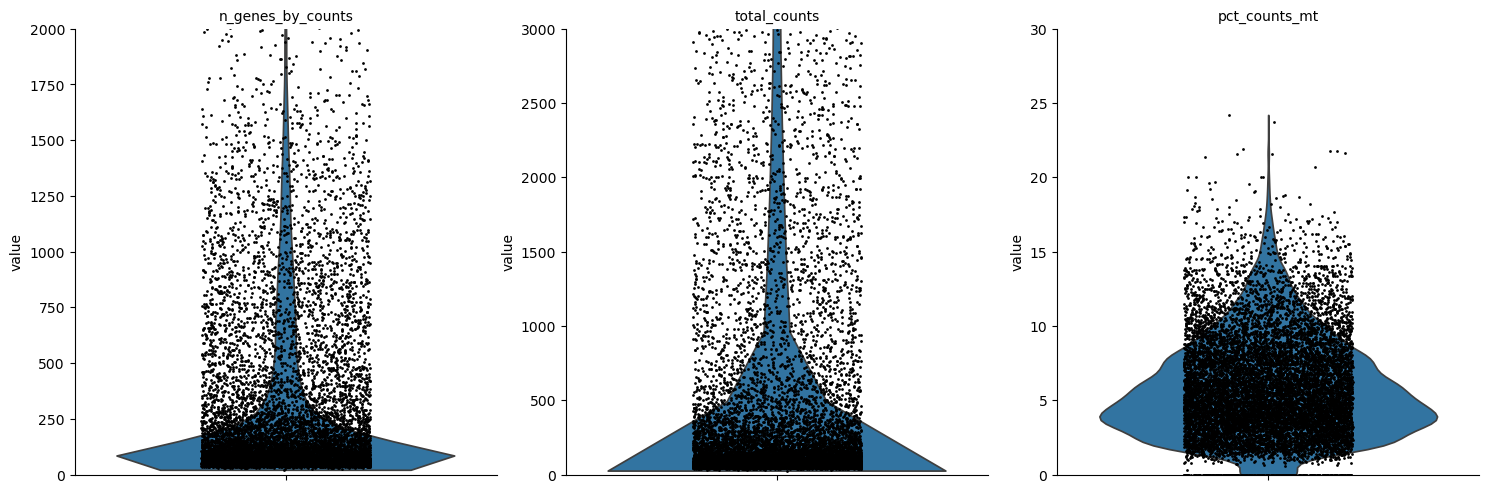

In [6]:
g = sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.2,
    size=2,
    multi_panel=True,
    show=False
)

g.axes.flat[0].set_ylim(0, 2000)  
g.axes.flat[1].set_ylim(0, 3000)  
g.axes.flat[2].set_ylim(0, 30)
plt.show()

In [7]:
adata = adata[
    (adata.obs["total_counts"] >= 100) &
    (adata.obs["n_genes_by_counts"] >= 80) &
    (adata.obs["pct_counts_mt"] < 15),
    :
].copy()

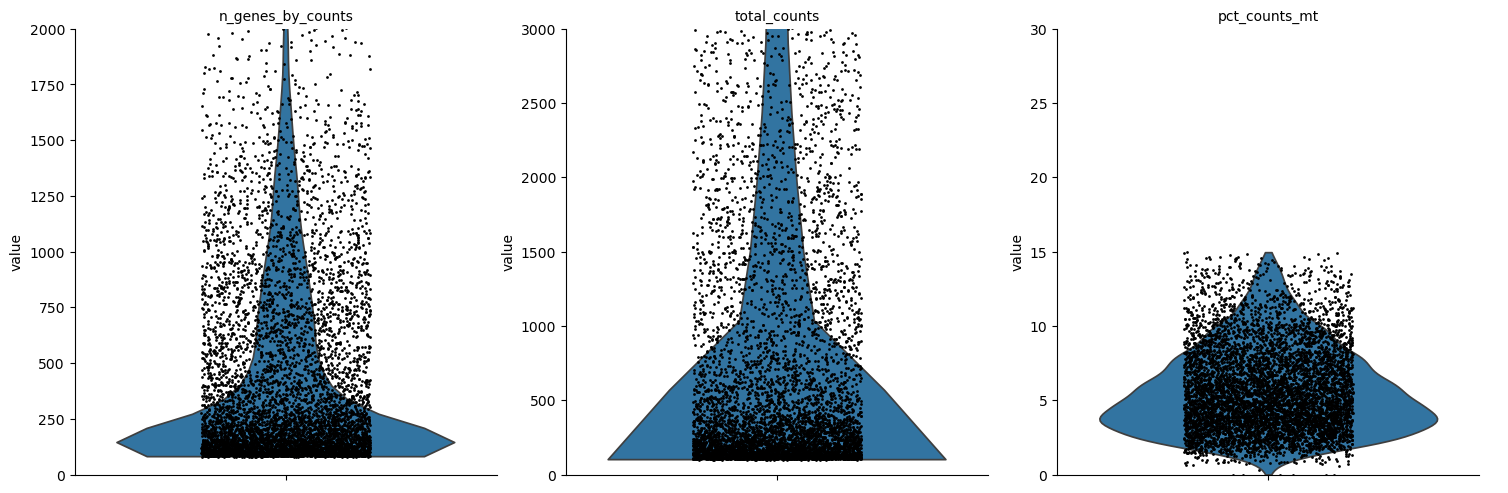

In [8]:
g = sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.2,
    size=2,
    multi_panel=True,
    show=False
)

g.axes.flat[0].set_ylim(0, 2000)  
g.axes.flat[1].set_ylim(0, 3000)  
g.axes.flat[2].set_ylim(0, 30)
plt.show()

In [9]:
adata.X.shape

(6390, 21792)

In [10]:
adata.raw=adata.X.copy()
adata.var_names = adata.var["Gene_name"].astype(str)
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=2000,
    flavor="seurat"
)
adata = adata[:, adata.var.highly_variable]
sc.pp.regress_out(adata, ['total_counts', 'pct_counts_mt'])
sc.tl.pca(adata)
sc.pp.scale(adata, max_value=10)
sc.pl.pca_variance_ratio(adata, log=True)
sc.pp.neighbors(adata, n_neighbors=20, n_pcs=30)
sc.tl.umap(adata, min_dist=0, spread=3)
sc.tl.leiden(adata, resolution = 1.7)
sc.pl.umap(adata, color=['leiden'])

ValueError: Can only init raw attribute with an AnnData object.

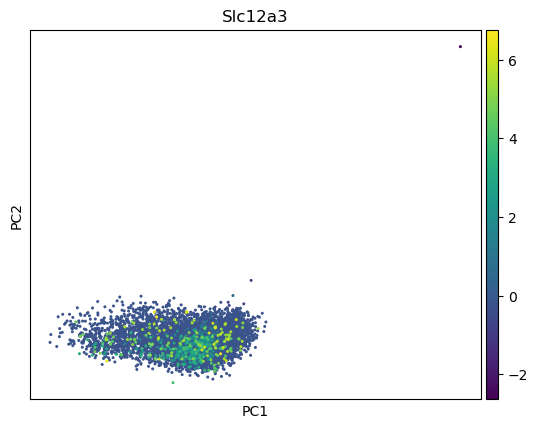

In [ ]:
sc.pl.pca(adata, color='Slc12a3')

In [ ]:
adata.obs

,total_UMI_count,not_aligned_UMI_count,not_aligned_ratio,Exon_count,Exon_ratio,UMI_count,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,leiden
Cell_name,,,,,,,,,,,,,,,,,,
old-cDNA.ACACCGTA-AACACGAC-ACCTGTTG-GCATGCTC,216,9.0,0.041667,204,0.944444,207.0,135,4.912655,207,5.337538,58.937198,83.091787,100.000000,100.0,5,1.791759,2.415459,16
old-cDNA.ACACCGTA-AACCAGGT-ACCGAATC-ATCGTGAC,382,12.0,0.031414,364,0.952880,370.0,245,5.505332,370,5.916202,47.297297,60.810811,87.837838,100.0,26,3.295837,7.027027,6
old-cDNA.ACACCGTA-AACGGAAG-AGGTAGAG-GATTGAGC,125,12.0,0.096000,109,0.872000,113.0,88,4.488636,113,4.736198,66.371681,100.000000,100.000000,100.0,13,2.639057,11.504425,4
old-cDNA.ACACCGTA-AAGAGGCA-AGCTTACC-AGCTTGGA,197,4.0,0.020305,191,0.969543,193.0,142,4.962845,193,5.267858,52.331606,78.238342,100.000000,100.0,10,2.397895,5.181347,14
old-cDNA.ACACCGTA-AATGCAGC-AACACGAC-GGATCGAT,213,11.0,0.051643,185,0.868545,202.0,154,5.043425,202,5.313206,48.514851,73.267327,100.000000,100.0,12,2.564949,5.940594,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
old-cDNA.TTTCCGCTT-TTCCGCTT-GAGAGAGT-GAGTGACT,437,18.0,0.041190,410,0.938215,419.0,280,5.638355,419,6.040255,43.198091,57.040573,80.906921,100.0,40,3.713572,9.546539,5
old-cDNA.TTTCCGCTT-TTCCGCTT-TCGAACCA-GAGTGACT,115,4.0,0.034783,110,0.956522,111.0,93,4.543295,111,4.718499,61.261261,100.000000,100.000000,100.0,11,2.484907,9.909910,4
old-cDNA.TTTCCGCTT-TTCTGAGG-ACAGCACT-AGCTCGTA,113,8.0,0.070796,102,0.902655,105.0,90,4.510860,105,4.663439,61.904762,100.000000,100.000000,100.0,4,1.609438,3.809524,0


In [ ]:
adata.obs['receiver_barcode'] = (
    adata.obs.index.astype(str)
    .str.replace(r"^[^.]*\.", "", regex=True)
    .str.replace("-", "", regex=False)
)

In [ ]:
adata.obs

,total_UMI_count,not_aligned_UMI_count,not_aligned_ratio,Exon_count,Exon_ratio,UMI_count,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,leiden,receiver_barcode
Cell_name,,,,,,,,,,,,,,,,,,,
old-cDNA.ACACCGTA-AACACGAC-ACCTGTTG-GCATGCTC,216,9.0,0.041667,204,0.944444,207.0,135,4.912655,207,5.337538,58.937198,83.091787,100.000000,100.0,5,1.791759,2.415459,16,ACACCGTAAACACGACACCTGTTGGCATGCTC
old-cDNA.ACACCGTA-AACCAGGT-ACCGAATC-ATCGTGAC,382,12.0,0.031414,364,0.952880,370.0,245,5.505332,370,5.916202,47.297297,60.810811,87.837838,100.0,26,3.295837,7.027027,6,ACACCGTAAACCAGGTACCGAATCATCGTGAC
old-cDNA.ACACCGTA-AACGGAAG-AGGTAGAG-GATTGAGC,125,12.0,0.096000,109,0.872000,113.0,88,4.488636,113,4.736198,66.371681,100.000000,100.000000,100.0,13,2.639057,11.504425,4,ACACCGTAAACGGAAGAGGTAGAGGATTGAGC
old-cDNA.ACACCGTA-AAGAGGCA-AGCTTACC-AGCTTGGA,197,4.0,0.020305,191,0.969543,193.0,142,4.962845,193,5.267858,52.331606,78.238342,100.000000,100.0,10,2.397895,5.181347,14,ACACCGTAAAGAGGCAAGCTTACCAGCTTGGA
old-cDNA.ACACCGTA-AATGCAGC-AACACGAC-GGATCGAT,213,11.0,0.051643,185,0.868545,202.0,154,5.043425,202,5.313206,48.514851,73.267327,100.000000,100.0,12,2.564949,5.940594,5,ACACCGTAAATGCAGCAACACGACGGATCGAT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
old-cDNA.TTTCCGCTT-TTCCGCTT-GAGAGAGT-GAGTGACT,437,18.0,0.041190,410,0.938215,419.0,280,5.638355,419,6.040255,43.198091,57.040573,80.906921,100.0,40,3.713572,9.546539,5,TTTCCGCTTTTCCGCTTGAGAGAGTGAGTGACT
old-cDNA.TTTCCGCTT-TTCCGCTT-TCGAACCA-GAGTGACT,115,4.0,0.034783,110,0.956522,111.0,93,4.543295,111,4.718499,61.261261,100.000000,100.000000,100.0,11,2.484907,9.909910,4,TTTCCGCTTTTCCGCTTTCGAACCAGAGTGACT
old-cDNA.TTTCCGCTT-TTCTGAGG-ACAGCACT-AGCTCGTA,113,8.0,0.070796,102,0.902655,105.0,90,4.510860,105,4.663439,61.904762,100.000000,100.000000,100.0,4,1.609438,3.809524,0,TTTCCGCTTTTCTGAGGACAGCACTAGCTCGTA


In [ ]:
file_path = "/p2/zulab/jtian/data/IRISeq/second/output/my-second-pipeline/old/connections/old-beads_spatial_reconstruction_umap.csv"
df = pd.read_csv(file_path)
print(df.head())

                   receiver_barcode  spatial_UMAP1  spatial_UMAP2
0  ACACCGTAAACAACCGAATGCAGCTGCGAAGT       0.170667       6.000897
1  ACACCGTAAACAACCGACAGCACTTCGAGACT       1.265942       5.182402
2  ACACCGTAAACAACCGACTTCGGTCTCTAACG      -1.255427       4.440651
3  ACACCGTAAACAACCGCAGTCGAACTCTAACG       0.571017       8.539664
4  ACACCGTAAACACGACACCTGTTGGCATGCTC      -1.508643       5.953121


In [ ]:
merged = adata.obs.merge(df, left_on="receiver_barcode", right_on="receiver_barcode", how="left", suffixes=('_adata', '_df'))

In [ ]:
merged

,total_UMI_count,not_aligned_UMI_count,not_aligned_ratio,Exon_count,Exon_ratio,UMI_count,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,leiden,receiver_barcode,spatial_UMAP1,spatial_UMAP2
0,216,9.0,0.041667,204,0.944444,207.0,135,4.912655,207,5.337538,58.937198,83.091787,100.000000,100.0,5,1.791759,2.415459,16,ACACCGTAAACACGACACCTGTTGGCATGCTC,-1.508643,5.953121
1,382,12.0,0.031414,364,0.952880,370.0,245,5.505332,370,5.916202,47.297297,60.810811,87.837838,100.0,26,3.295837,7.027027,6,ACACCGTAAACCAGGTACCGAATCATCGTGAC,-1.559826,4.805163
2,125,12.0,0.096000,109,0.872000,113.0,88,4.488636,113,4.736198,66.371681,100.000000,100.000000,100.0,13,2.639057,11.504425,4,ACACCGTAAACGGAAGAGGTAGAGGATTGAGC,-1.269684,6.233314
3,197,4.0,0.020305,191,0.969543,193.0,142,4.962845,193,5.267858,52.331606,78.238342,100.000000,100.0,10,2.397895,5.181347,14,ACACCGTAAAGAGGCAAGCTTACCAGCTTGGA,1.694675,2.812598
4,213,11.0,0.051643,185,0.868545,202.0,154,5.043425,202,5.313206,48.514851,73.267327,100.000000,100.0,12,2.564949,5.940594,5,ACACCGTAAATGCAGCAACACGACGGATCGAT,0.642266,3.620403
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6385,437,18.0,0.041190,410,0.938215,419.0,280,5.638355,419,6.040255,43.198091,57.040573,80.906921,100.0,40,3.713572,9.546539,5,TTTCCGCTTTTCCGCTTGAGAGAGTGAGTGACT,-2.063426,4.068395
6386,115,4.0,0.034783,110,0.956522,111.0,93,4.543295,111,4.718499,61.261261,100.000000,100.000000,100.0,11,2.484907,9.909910,4,TTTCCGCTTTTCCGCTTTCGAACCAGAGTGACT,-1.406989,4.091393
6387,113,8.0,0.070796,102,0.902655,105.0,90,4.510860,105,4.663439,61.904762,100.000000,100.000000,100.0,4,1.609438,3.809524,0,TTTCCGCTTTTCTGAGGACAGCACTAGCTCGTA,-1.494054,3.446046
6388,116,9.0,0.077586,104,0.896552,107.0,82,4.418841,107,4.682131,70.093458,100.000000,100.000000,100.0,8,2.197225,7.476636,4,TTTCCGCTTTTGTTCCGGACTTGAGTCACGGAT,-1.065572,7.140631


In [ ]:
adata.obs = merged.copy()
adata.obsm['X_umap_beads'] = adata.obs[['spatial_UMAP1',"spatial_UMAP2"]].values

/p1/zulab_users/jtian/anaconda3/envs/my_IRISeq_py38/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


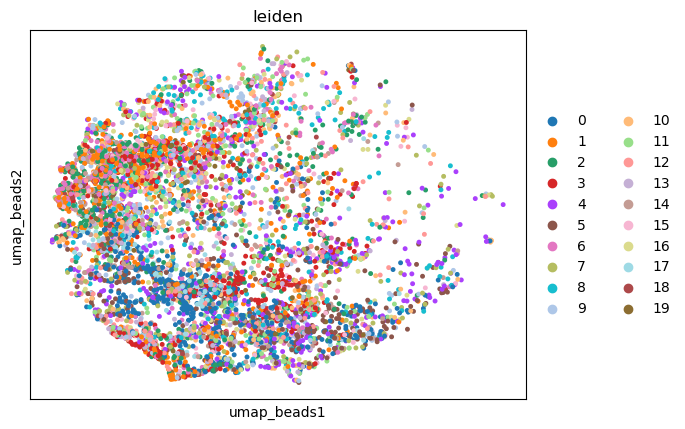

In [ ]:
sc.pl.embedding(adata, basis="umap_beads", color=["leiden"], s=50)

In [ ]:
adata

AnnData object with n_obs × n_vars = 6390 × 2000
    obs: 'total_UMI_count', 'not_aligned_UMI_count', 'not_aligned_ratio', 'Exon_count', 'Exon_ratio', 'UMI_count', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'leiden', 'receiver_barcode', 'spatial_UMAP1', 'spatial_UMAP2'
    var: 'Gene_type', 'Gene_name', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden', 'leiden_colors'
    obsm: 'X_pca', 'X_umap', 'X_umap_beads'
    varm: 'PCs'
    layers: 'raw'
    obsp: 'distances', 'connectivities'

Found marker genes: 4 ['Kap', 'Slc12a3', 'Aqp2', 'Acta2']
Skipped missing marker genes: 29 ['Lrp2', 'Slc34a1', 'Slc5a2', 'Umod', 'Slc12a1', 'Pvalb', 'Calb1', 'Trpv5', 'Aqp3', 'Avpr2', 'Atp6v1g3', 'Atp6v0d2', 'Slc4a1', 'Slc26a4', 'Foxi1', 'Nphs1', 'Nphs2', 'Podxl', 'Pecam1', 'Kdr', 'Emcn', 'Col1a1', 'Dcn', 'Pdgfrb', 'Tagln', 'Rgs5', 'Ptprc', 'Lyz2', 'C1qa']


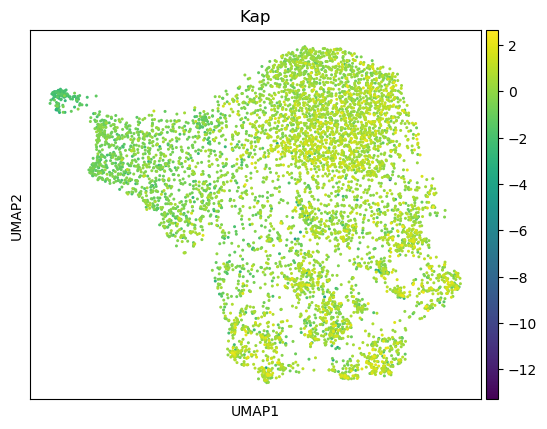

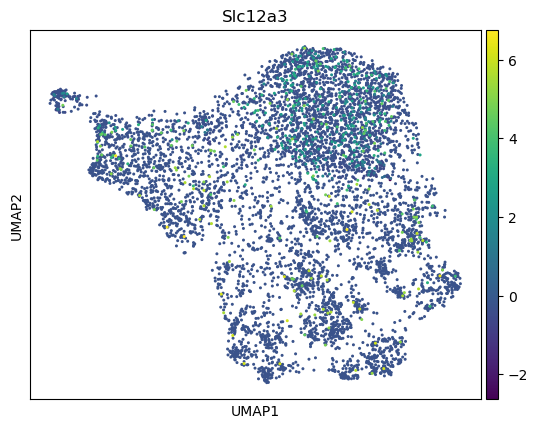

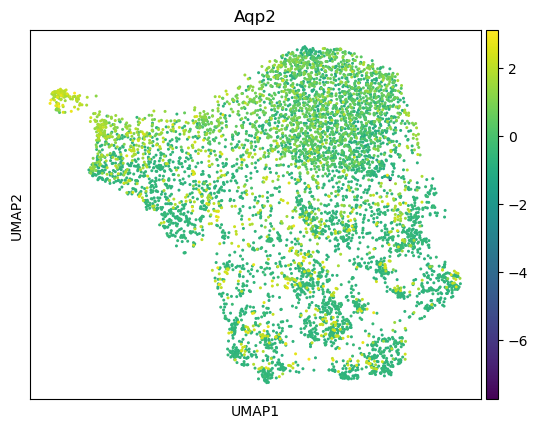

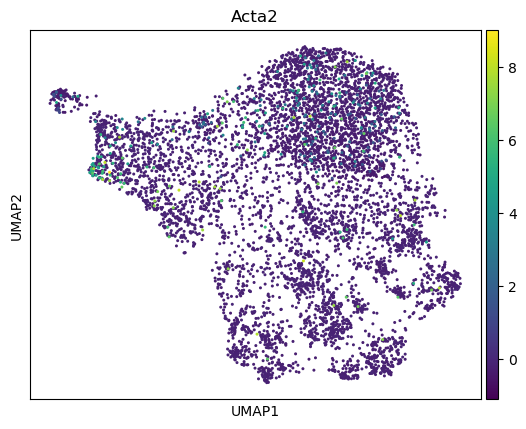

In [ ]:
kidney_marker_genes = [
    'Lrp2', 'Slc34a1', 'Slc5a2', 'Kap',
    'Umod', 'Slc12a1',
    'Slc12a3', 'Pvalb',
    'Calb1', 'Trpv5',
    'Aqp2', 'Aqp3', 'Avpr2',
    'Atp6v1g3', 'Atp6v0d2', 'Slc4a1', 'Slc26a4', 'Foxi1',
    'Nphs1', 'Nphs2', 'Podxl',
    'Pecam1', 'Kdr', 'Emcn',
    'Col1a1', 'Dcn', 'Pdgfrb',
    'Acta2', 'Tagln', 'Rgs5',
    'Ptprc', 'Lyz2', 'C1qa',
]

available_genes = set(adata.var_names.astype(str))
found_genes = [gene for gene in kidney_marker_genes if gene in available_genes]
missing_genes = [gene for gene in kidney_marker_genes if gene not in available_genes]

print('Found marker genes:', len(found_genes), found_genes)
print('Skipped missing marker genes:', len(missing_genes), missing_genes)

for gene in found_genes:
    sc.pl.umap(adata, color=[gene], title=gene)


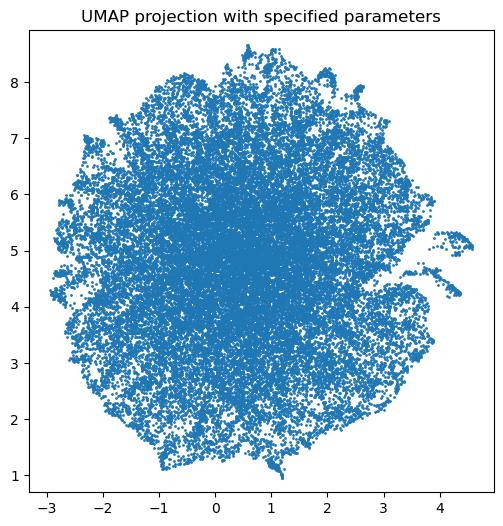

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(df["spatial_UMAP1"], df["spatial_UMAP2"], s=1)
plt.gca().set_aspect("equal", "datalim")
plt.title("UMAP projection with specified parameters")
plt.show()

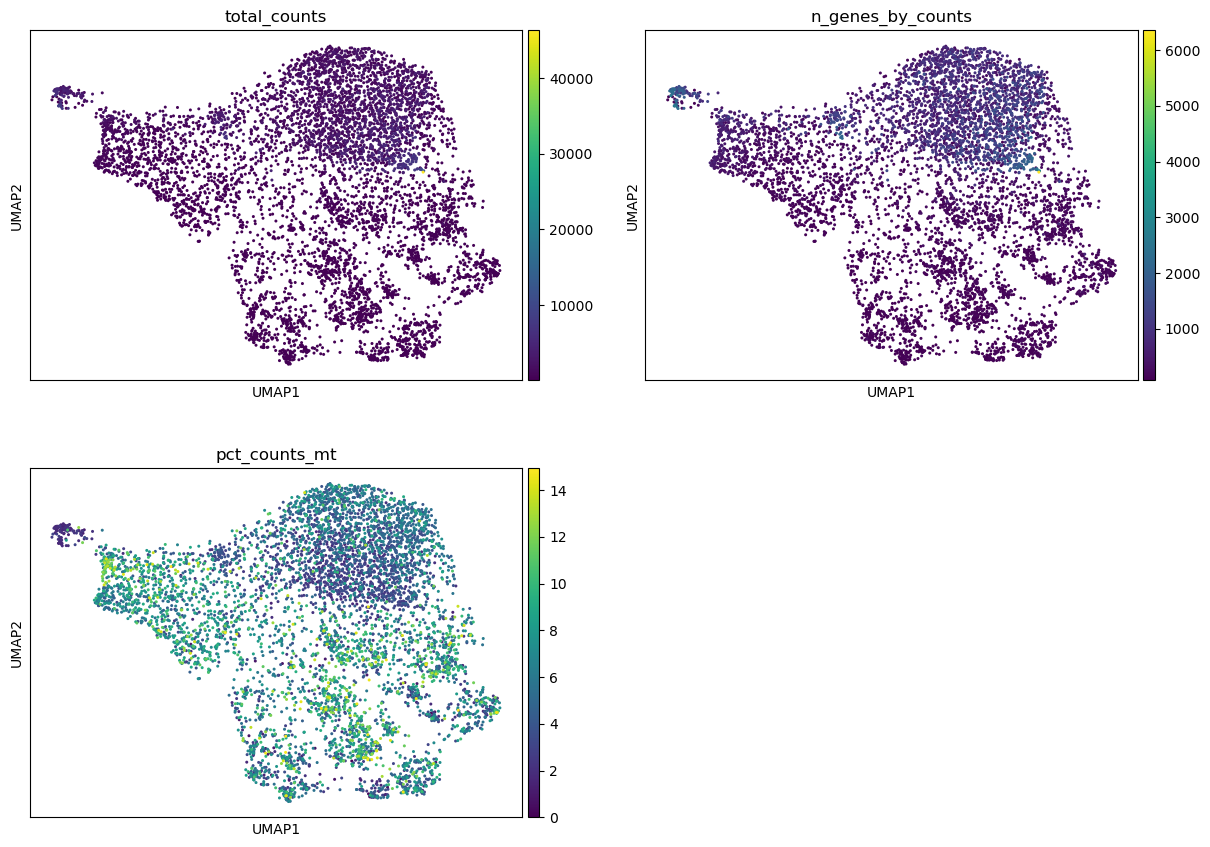

In [ ]:
qc_cols = [col for col in ["total_counts", "n_genes_by_counts", "pct_counts_mt"] if col in adata.obs.columns]
if len(qc_cols) > 0:
   sc.pl.umap(
     adata,
     color=qc_cols,
     ncols=2
   )

In [ ]:
sc.pl.umap(adata, color=["Slc12a3"], layer="raw")
marker_genes = ["MS4A1", "CD3D", "CD8A", "LYZ", "NKG7", "PPBP"]

if adata.raw is not None:
    marker_genes = [gene for gene in marker_genes if gene in adata.raw.var_names]
    if len(marker_genes) > 0:
        sc.pl.umap(
            adata,
            color=["leiden_res0_5"] + marker_genes,
            use_raw=True,
            ncols=3
        )